## Finding puck boresight

### PLot ECCR trajectory

Loaded SBET: /media/b085164/LaCie/2026_RD/ECCR/TRAJ/V02/02_APPLANIX/ECCR_V02_MLS_PPC/ECCR_MLS_PUCK/Proc/sbet_ECCR_MLS_PUCK.out
Records: 1,150,527
Time range: [313798.0043, 319551.0044]


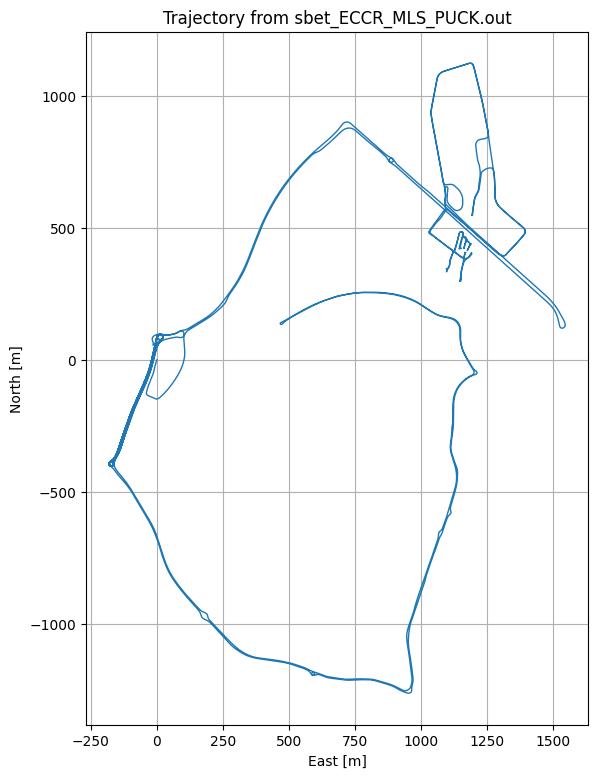

In [6]:
# ============================================================
# Load ONE SBET and plot an interactive single trajectory
# - autonomous cell
# - click on trajectory -> shows GPS time
# - zoom / pan enabled
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# USER INPUT
# ------------------------------------------------------------
sbet_path = Path("/media/b085164/LaCie/2026_RD/ECCR/TRAJ/V02/02_APPLANIX/ECCR_V02_MLS_PPC/ECCR_MLS_PUCK/Proc/sbet_ECCR_MLS_PUCK.out")

# Optional time window
t_start = None   # e.g. 305300.0
t_end   = None   # e.g. 305500.0

# Optional decimation for display
max_display_points = 50000

# ------------------------------------------------------------
# Standard Applanix SBET dtype (17 float64 values per record)
# ------------------------------------------------------------
SBET_DTYPE = np.dtype([
    ("time",        np.float64),
    ("lat",         np.float64),
    ("lon",         np.float64),
    ("alt",         np.float64),
    ("vx",          np.float64),
    ("vy",          np.float64),
    ("vz",          np.float64),
    ("roll",        np.float64),
    ("pitch",       np.float64),
    ("heading",     np.float64),
    ("wander",      np.float64),
    ("ax",          np.float64),
    ("ay",          np.float64),
    ("az",          np.float64),
    ("wx",          np.float64),
    ("wy",          np.float64),
    ("wz",          np.float64),
])

def load_sbet(path: Path) -> pd.DataFrame:
    arr = np.fromfile(path, dtype=SBET_DTYPE)
    if arr.size == 0:
        raise ValueError(f"Empty or unreadable SBET file: {path}")
    return pd.DataFrame(arr)

def geodetic_to_local_enu(lat, lon, h, lat0, lon0, h0):
    a = 6378137.0
    f = 1 / 298.257223563
    e2 = f * (2 - f)

    def geodetic_to_ecef(lat, lon, h):
        sin_lat = np.sin(lat)
        cos_lat = np.cos(lat)
        sin_lon = np.sin(lon)
        cos_lon = np.cos(lon)
        N = a / np.sqrt(1 - e2 * sin_lat**2)
        X = (N + h) * cos_lat * cos_lon
        Y = (N + h) * cos_lat * sin_lon
        Z = (N * (1 - e2) + h) * sin_lat
        return X, Y, Z

    X, Y, Z = geodetic_to_ecef(lat, lon, h)
    X0, Y0, Z0 = geodetic_to_ecef(lat0, lon0, h0)

    dX = X - X0
    dY = Y - Y0
    dZ = Z - Z0

    sin_lat0 = np.sin(lat0)
    cos_lat0 = np.cos(lat0)
    sin_lon0 = np.sin(lon0)
    cos_lon0 = np.cos(lon0)

    R = np.array([
        [-sin_lon0,              cos_lon0,             0],
        [-sin_lat0*cos_lon0, -sin_lat0*sin_lon0, cos_lat0],
        [ cos_lat0*cos_lon0,  cos_lat0*sin_lon0, sin_lat0],
    ])

    xyz = np.vstack([dX, dY, dZ])
    enu = R @ xyz
    return enu[0], enu[1], enu[2]

# ------------------------------------------------------------
# Load and filter
# ------------------------------------------------------------
df = load_sbet(sbet_path)

print(f"Loaded SBET: {sbet_path}")
print(f"Records: {len(df):,}")
print(f"Time range: [{df.time.min():.4f}, {df.time.max():.4f}]")

mask = np.ones(len(df), dtype=bool)
if t_start is not None:
    mask &= df.time.to_numpy() >= t_start
if t_end is not None:
    mask &= df.time.to_numpy() <= t_end

dfw = df.loc[mask].copy()
if len(dfw) == 0:
    raise ValueError("No samples in selected time window.")

lat = dfw.lat.to_numpy()
lon = dfw.lon.to_numpy()
alt = dfw.alt.to_numpy()
time_gps = dfw.time.to_numpy()

lat0, lon0, h0 = lat[0], lon[0], alt[0]
E, N, U = geodetic_to_local_enu(lat, lon, alt, lat0, lon0, h0)

# Optional decimation
n = len(time_gps)
if n > max_display_points:
    idx = np.linspace(0, n - 1, max_display_points).astype(int)
    E = E[idx]
    N = N[idx]
    time_gps = time_gps[idx]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 9))
ax.plot(E, N, '-', lw=1)
ax.set_title(f"Trajectory from {sbet_path.name}")
ax.set_xlabel("East [m]")
ax.set_ylabel("North [m]")
ax.set_aspect('equal', adjustable='box')
ax.grid(True)

selected_pt, = ax.plot([], [], 'rx', ms=10, mew=2)
annotation = ax.annotate(
    "",
    xy=(0, 0),
    xytext=(10, 10),
    textcoords="offset points",
    bbox=dict(boxstyle="round", fc="white", alpha=0.8),
)
annotation.set_visible(False)

def on_click(event):
    if event.inaxes != ax or event.xdata is None or event.ydata is None:
        return

    dx = E - event.xdata
    dy = N - event.ydata
    i = np.argmin(dx * dx + dy * dy)

    e_sel = E[i]
    n_sel = N[i]
    t_sel = time_gps[i]

    selected_pt.set_data([e_sel], [n_sel])
    annotation.xy = (e_sel, n_sel)
    annotation.set_text(
        f"GPS time: {t_sel:.4f}\n"
        f"E: {e_sel:.3f} m\n"
        f"N: {n_sel:.3f} m\n"
        f"idx: {i}"
    )
    annotation.set_visible(True)

    print(f"Selected point -> GPS time: {t_sel:.4f} | E={e_sel:.3f} m | N={n_sel:.3f} m")
    fig.canvas.draw_idle()

cid = fig.canvas.mpl_connect("button_press_event", on_click)
plt.show()

### Extract subclouds

In [25]:
from pathlib import Path
from collections import defaultdict
import numpy as np
import laspy

# ============================================================
# GLOBAL ASCII OPTIONS
# ============================================================
delimiter = ","
skiprows = 0
time_col = 0

# ============================================================
# JOB LIST
# ============================================================
jobs = [
    {
        "input_cloud": Path("/media/b085164/Elements/CALIB_26_02_25/georef_puck/test_puck/PUCK/lidar_20260225_124315_pcd.las"),
        "start": 305080.0,
        "end": 305090.0,
        "output_cloud": Path("/media/b085164/Elements/CALIB_26_02_25/georef_puck/PUCK/calib/output_cloud_1.las"),
    },
    {
        "input_cloud": Path("/media/b085164/Elements/CALIB_26_02_25/georef_VUX/merged/HA_LR/merged_1000_HA_LR.las"),
        "start": 305080.0,
        "end": 305090.0,
        "output_cloud": Path("/media/b085164/Elements/CALIB_26_02_25/georef_puck/PUCK/calib/output_cloud_2.las"),
    },
    
]

# ============================================================
# HELPERS
# ============================================================
def extract_many_las_by_time(infile: Path, file_jobs: list[dict]):
    las = laspy.read(infile)

    if "gps_time" not in las.point_format.dimension_names:
        raise ValueError(f"No gps_time found in LAS file: {infile}")

    gps_time = np.asarray(las.gps_time)
    n_total = len(gps_time)

    print(f"\n[LAS] Loaded once: {infile}")
    print(f"      total points: {n_total}")

    for job in file_jobs:
        t0 = float(job["start"])
        t1 = float(job["end"])
        outfile = Path(job["output_cloud"])

        mask = (gps_time >= t0) & (gps_time <= t1)
        n_kept = int(mask.sum())

        if n_kept == 0:
            print(f"[WARN] No LAS points found in [{t0}, {t1}] for {infile.name}")
            continue

        sub = laspy.LasData(las.header)
        sub.points = las.points[mask]

        outfile.parent.mkdir(parents=True, exist_ok=True)
        sub.write(outfile)

        print(f"[LAS] {outfile}")
        print(f"      kept {n_kept}/{n_total} points in [{t0}, {t1}]")

def extract_many_ascii_by_time(
    infile: Path,
    file_jobs: list[dict],
    delimiter=",",
    skiprows=0,
    time_col=0,
):
    arr = np.loadtxt(infile, delimiter=delimiter, skiprows=skiprows)

    if arr.ndim == 1:
        arr = arr.reshape(1, -1)

    time = arr[:, time_col]
    n_total = len(time)

    print(f"\n[ASCII] Loaded once: {infile}")
    print(f"        total rows: {n_total}")

    for job in file_jobs:
        t0 = float(job["start"])
        t1 = float(job["end"])
        outfile = Path(job["output_cloud"])

        mask = (time >= t0) & (time <= t1)
        n_kept = int(mask.sum())

        if n_kept == 0:
            print(f"[WARN] No ASCII rows found in [{t0}, {t1}] for {infile.name}")
            continue

        sub = arr[mask]

        outfile.parent.mkdir(parents=True, exist_ok=True)
        np.savetxt(outfile, sub, delimiter=delimiter, fmt="%.10f")

        print(f"[ASCII] {outfile}")
        print(f"        kept {n_kept}/{n_total} rows in [{t0}, {t1}]")

# ============================================================
# GROUP JOBS BY INPUT FILE
# ============================================================
jobs_by_input = defaultdict(list)
for job in jobs:
    jobs_by_input[Path(job["input_cloud"])].append(job)

# ============================================================
# RUN
# ============================================================
for i, (infile, file_jobs) in enumerate(jobs_by_input.items(), start=1):
    print("\n" + "=" * 60)
    print(f"INPUT FILE {i}/{len(jobs_by_input)}")
    print("=" * 60)

    if not infile.exists():
        print(f"[ERROR] Input file does not exist: {infile}")
        continue

    suffix = infile.suffix.lower()

    if suffix in [".las", ".laz"]:
        extract_many_las_by_time(infile, file_jobs)

    elif suffix in [".txt", ".csv", ".asc"]:
        extract_many_ascii_by_time(
            infile,
            file_jobs,
            delimiter=delimiter,
            skiprows=skiprows,
            time_col=time_col,
        )
    else:
        raise ValueError(f"Unsupported input format: {suffix}")


INPUT FILE 1/2

[LAS] Loaded once: /media/b085164/Elements/CALIB_26_02_25/georef_puck/test_puck/PUCK/lidar_20260225_124315_pcd.las
      total points: 45459189
[LAS] /media/b085164/Elements/CALIB_26_02_25/georef_puck/PUCK/calib/output_cloud_1.las
      kept 1117804/45459189 points in [305080.0, 305090.0]

INPUT FILE 2/2

[LAS] Loaded once: /media/b085164/Elements/CALIB_26_02_25/georef_VUX/merged/HA_LR/merged_1000_HA_LR.las
      total points: 319116685
[LAS] /media/b085164/Elements/CALIB_26_02_25/georef_puck/PUCK/calib/output_cloud_2.las
      kept 9376366/319116685 points in [305080.0, 305090.0]


## Crop nuage 

In [4]:
from pathlib import Path
import numpy as np
import laspy
from matplotlib.path import Path as MplPath

# ============================================================
# INPUT / OUTPUT JOBS
# ============================================================
jobs = [
    {
        "input_cloud": Path("/media/b085164/Elements/CALIB_26_02_25/crops/georef_puck/PUCK/lidar_20260225_124315_pcd.las"),
        "output_cloud": Path("/media/b085164/Elements/CALIB_26_02_25/crops/v2/cloud_1.las"),
    },
    {
        "input_cloud": Path("/media/b085164/Elements/CALIB_26_02_25/crops/georef_puck/PUCK/lidar_20260225_125030_pcd.las"),
        "output_cloud": Path("/media/b085164/Elements/CALIB_26_02_25/crops/v2/cloud_2.las"),
    },
]

# ============================================================
# RECTANGLE CORNERS (global coords Xg, Yg)
# ============================================================
corners = np.array([
    [2542337.899994, 1157075.195007],
    [2542354.688995, 1157096.387024],
    [2542392.407013, 1157065.625977],
    [2542375.092987, 1157043.383972],
], dtype=np.float64)

# ============================================================
# PARAMETERS
# ============================================================
time_gap_threshold = 0.5  # seconds

# ============================================================
# HELPERS
# ============================================================
def order_polygon_points(pts):
    c = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - c[1], pts[:, 0] - c[0])
    return pts[np.argsort(ang)]

def crop_first_passage_las(input_cloud: Path, output_cloud: Path, polygon_xy: np.ndarray, time_gap_threshold: float = 0.5):
    las = laspy.read(input_cloud)

    if "gps_time" not in las.point_format.dimension_names:
        raise ValueError(f"'gps_time' not found in {input_cloud}")

    x = np.asarray(las.x)
    y = np.asarray(las.y)
    gps_time = np.asarray(las.gps_time)

    poly = order_polygon_points(polygon_xy)
    poly_path = MplPath(poly)

    xy = np.column_stack((x, y))
    mask_spatial = poly_path.contains_points(xy)

    n_spatial = int(mask_spatial.sum())
    print(f"\n[INPUT] {input_cloud.name}")
    print(f"Total points: {len(las.points)}")
    print(f"Points inside rectangle: {n_spatial}")

    if n_spatial == 0:
        print("[WARN] No points found inside rectangle.")
        return

    idx_spatial = np.where(mask_spatial)[0]
    t_spatial = gps_time[idx_spatial]

    order = np.argsort(t_spatial)
    idx_sorted = idx_spatial[order]
    t_sorted = t_spatial[order]

    dt = np.diff(t_sorted)
    breaks = np.where(dt > time_gap_threshold)[0]

    if len(breaks) == 0:
        idx_first_pass = idx_sorted
    else:
        idx_first_pass = idx_sorted[:breaks[0] + 1]

    n_first = len(idx_first_pass)
    t0 = float(gps_time[idx_first_pass].min())
    t1 = float(gps_time[idx_first_pass].max())

    sub = laspy.LasData(las.header)
    sub.points = las.points[idx_first_pass]

    output_cloud.parent.mkdir(parents=True, exist_ok=True)
    sub.write(output_cloud)

    print(f"First passage kept: {n_first} points")
    print(f"Time range: [{t0:.6f}, {t1:.6f}]")
    print(f"Saved: {output_cloud}")

# ============================================================
# RUN
# ============================================================
for job in jobs:
    crop_first_passage_las(
        input_cloud=job["input_cloud"],
        output_cloud=job["output_cloud"],
        polygon_xy=corners,
        time_gap_threshold=time_gap_threshold,
    )


[INPUT] lidar_20260225_124315_pcd.las
Total points: 45459189
Points inside rectangle: 244776
First passage kept: 244776 points
Time range: [305085.633392, 305090.983550]
Saved: /media/b085164/Elements/CALIB_26_02_25/crops/v2/cloud_1.las

[INPUT] lidar_20260225_125030_pcd.las
Total points: 161935392
Points inside rectangle: 638261
First passage kept: 199949 points
Time range: [305981.530989, 305986.594932]
Saved: /media/b085164/Elements/CALIB_26_02_25/crops/v2/cloud_2.las


In [2]:
# ============================================================
# Compare TWO binary SBET .out trajectories in one interactive plot
# - autonomous cell
# - Plotly interactive: zoom / pan / hover / legend toggle
# - common local ENU frame
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# ------------------------------------------------------------
# USER INPUT
# ------------------------------------------------------------
out2_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/base_v0/in/reference.out") #JV
out3_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/outage/outage_GNSS/out/ODyN_outage.out") # ODyN

label2 = "sbet JV"
label3 = "sbet ODyN"


# Optional time window
t_start = None   # e.g. 466930.0
t_end   = None   # e.g. 466980.0

# Optional decimation for display
max_display_points = 50000

# ------------------------------------------------------------
# Standard Applanix SBET dtype (17 float64 values per record)
# ------------------------------------------------------------
SBET_DTYPE = np.dtype([
    ("time",        np.float64),
    ("lat",         np.float64),
    ("lon",         np.float64),
    ("alt",         np.float64),
    ("vx",          np.float64),
    ("vy",          np.float64),
    ("vz",          np.float64),
    ("roll",        np.float64),
    ("pitch",       np.float64),
    ("heading",     np.float64),
    ("wander",      np.float64),
    ("ax",          np.float64),
    ("ay",          np.float64),
    ("az",          np.float64),
    ("wx",          np.float64),
    ("wy",          np.float64),
    ("wz",          np.float64),
])

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def load_sbet(path: Path) -> pd.DataFrame:
    arr = np.fromfile(path, dtype=SBET_DTYPE)
    if arr.size == 0:
        raise ValueError(f"Empty or unreadable SBET file: {path}")
    return pd.DataFrame(arr)

def geodetic_to_local_enu(lat, lon, h, lat0, lon0, h0):
    a = 6378137.0
    f = 1 / 298.257223563
    e2 = f * (2 - f)

    def geodetic_to_ecef(lat, lon, h):
        sin_lat = np.sin(lat)
        cos_lat = np.cos(lat)
        sin_lon = np.sin(lon)
        cos_lon = np.cos(lon)
        N = a / np.sqrt(1 - e2 * sin_lat**2)
        X = (N + h) * cos_lat * cos_lon
        Y = (N + h) * cos_lat * sin_lon
        Z = (N * (1 - e2) + h) * sin_lat
        return X, Y, Z

    X, Y, Z = geodetic_to_ecef(lat, lon, h)
    X0, Y0, Z0 = geodetic_to_ecef(lat0, lon0, h0)

    dX = X - X0
    dY = Y - Y0
    dZ = Z - Z0

    sin_lat0 = np.sin(lat0)
    cos_lat0 = np.cos(lat0)
    sin_lon0 = np.sin(lon0)
    cos_lon0 = np.cos(lon0)

    R = np.array([
        [-sin_lon0,               cos_lon0,              0],
        [-sin_lat0 * cos_lon0, -sin_lat0 * sin_lon0,  cos_lat0],
        [ cos_lat0 * cos_lon0,  cos_lat0 * sin_lon0,  sin_lat0],
    ])

    xyz = np.vstack([dX, dY, dZ])
    enu = R @ xyz
    return enu[0], enu[1], enu[2]

def filter_time_window(df, t_start=None, t_end=None):
    mask = np.ones(len(df), dtype=bool)
    if t_start is not None:
        mask &= df["time"].to_numpy() >= t_start
    if t_end is not None:
        mask &= df["time"].to_numpy() <= t_end
    out = df.loc[mask].copy()
    if len(out) == 0:
        raise ValueError("No samples in selected time window.")
    return out

def decimate_indices(n, max_points):
    if n <= max_points:
        return np.arange(n)
    return np.linspace(0, n - 1, max_points).astype(int)

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------
df2 = load_sbet(out2_path)
df3 = load_sbet(out3_path)

print(f"Loaded 2: {out2_path}")
print(f"  records: {len(df2):,}")
print(f"  time range: [{df2.time.min():.4f}, {df2.time.max():.4f}]")

print(f"Loaded 3: {out3_path}")
print(f"  records: {len(df3):,}")
print(f"  time range: [{df3.time.min():.4f}, {df3.time.max():.4f}]")

# ------------------------------------------------------------
# Filter time window
# ------------------------------------------------------------
df2 = filter_time_window(df2, t_start, t_end)
df3 = filter_time_window(df3, t_start, t_end)

# ------------------------------------------------------------
# Common ENU origin
# Use first point of trajectory 1 as reference
# ------------------------------------------------------------
lat0 = df2["lat"].iloc[0]
lon0 = df2["lon"].iloc[0]
h0   = df2["alt"].iloc[0]


E2, N2, U2 = geodetic_to_local_enu(
    df2["lat"].to_numpy(),
    df2["lon"].to_numpy(),
    df2["alt"].to_numpy(),
    lat0, lon0, h0
)

E3, N3, U3 = geodetic_to_local_enu(
    df3["lat"].to_numpy(),
    df3["lon"].to_numpy(),
    df3["alt"].to_numpy(),
    lat0, lon0, h0
)


t2 = df2["time"].to_numpy()
t3 = df3["time"].to_numpy()

# ------------------------------------------------------------
# Optional decimation
# ------------------------------------------------------------
idx2 = decimate_indices(len(t2), max_display_points)
idx3 = decimate_indices(len(t3), max_display_points)


E2, N2, U2, t2 = E2[idx2], N2[idx2], U2[idx2], t2[idx2]
E3, N3, U3, t3 = E3[idx3], N3[idx3], U3[idx3], t3[idx3]


# ------------------------------------------------------------
# Interactive plot
# ------------------------------------------------------------
fig = go.Figure()

fig.add_trace(go.Scattergl(
    x=E2,
    y=N2,
    mode="lines",
    name=label2,
    customdata=np.column_stack([t2, U2]),
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "GPS time: %{customdata[0]:.4f}<br>"
        "East: %{x:.3f} m<br>"
        "North: %{y:.3f} m<br>"
        "Up: %{customdata[1]:.3f} m"
        "<extra></extra>"
    )
))

fig.add_trace(go.Scattergl(
    x=E3,
    y=N3,
    mode="lines",
    name=label3,
    customdata=np.column_stack([t3, U3]),
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "GPS time: %{customdata[0]:.4f}<br>"
        "East: %{x:.3f} m<br>"
        "North: %{y:.3f} m<br>"
        "Up: %{customdata[1]:.3f} m"
        "<extra></extra>"
    )
))

fig.update_layout(
    title="Comparison of three SBET trajectories",
    xaxis_title="East [m]",
    yaxis_title="North [m]",
    template="plotly_white",
    height=850,
    width=950,
    hovermode="closest",
    legend=dict(
        x=0.01,
        y=0.99,
        bgcolor="rgba(255,255,255,0.8)"
    )
)

fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1
)

fig.show()

Loaded 2: /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/base_v0/in/reference.out
  records: 556,368
  time range: [304508.0000, 307276.0000]
Loaded 3: /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/outage/outage_GNSS/out/ODyN_outage.out
  records: 39,900
  time range: [304790.0043, 306784.9543]


### Statistiques

In [42]:
# ============================================================
# Statistics between TWO SBET trajectories
# - uses df2 / df3 already loaded and filtered in time
# - interpolates traj 3 onto traj 2 timestamps
# - computes ENU residual statistics
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------
for name, df in [("df2", df2), ("df3", df3)]:
    if len(df) < 2:
        raise ValueError(f"{name} has fewer than 2 samples.")

# Sort by time just in case
df2s = df2.sort_values("time").reset_index(drop=True).copy()
df3s = df3.sort_values("time").reset_index(drop=True).copy()

t2_full = df2s["time"].to_numpy(dtype=np.float64)
t3_full = df3s["time"].to_numpy(dtype=np.float64)

# ------------------------------------------------------------
# Common time overlap
# ------------------------------------------------------------
t_min = max(t2_full.min(), t3_full.min())
t_max = min(t2_full.max(), t3_full.max())

if t_max <= t_min:
    raise ValueError("No common time overlap between the two trajectories.")

mask2 = (t2_full >= t_min) & (t2_full <= t_max)
df2c = df2s.loc[mask2].copy()
t_ref = df2c["time"].to_numpy(dtype=np.float64)

if len(t_ref) < 2:
    raise ValueError("Not enough common samples after time-overlap filtering.")

print(f"Common time overlap: [{t_min:.6f}, {t_max:.6f}]")
print(f"Reference samples used from traj 2: {len(t_ref):,}")

# ------------------------------------------------------------
# Common ENU origin
# Same convention as your previous cell
# ------------------------------------------------------------
lat0 = df2s["lat"].iloc[0]
lon0 = df2s["lon"].iloc[0]
h0   = df2s["alt"].iloc[0]

# Traj 2 in ENU
E2c, N2c, U2c = geodetic_to_local_enu(
    df2c["lat"].to_numpy(dtype=np.float64),
    df2c["lon"].to_numpy(dtype=np.float64),
    df2c["alt"].to_numpy(dtype=np.float64),
    lat0, lon0, h0
)

# Traj 3 in ENU on its own timestamps
E3_full, N3_full, U3_full = geodetic_to_local_enu(
    df3s["lat"].to_numpy(dtype=np.float64),
    df3s["lon"].to_numpy(dtype=np.float64),
    df3s["alt"].to_numpy(dtype=np.float64),
    lat0, lon0, h0
)

# ------------------------------------------------------------
# Interpolate traj 3 onto traj 2 timestamps
# ------------------------------------------------------------
E3i = np.interp(t_ref, t3_full, E3_full)
N3i = np.interp(t_ref, t3_full, N3_full)
U3i = np.interp(t_ref, t3_full, U3_full)

# Residuals: traj3 - traj2
dE = E3i - E2c
dN = N3i - N2c
dU = U3i - U2c

err_2d = np.sqrt(dE**2 + dN**2)
err_3d = np.sqrt(dE**2 + dN**2 + dU**2)

# ------------------------------------------------------------
# Stats helper
# ------------------------------------------------------------
def axis_stats(arr):
    arr = np.asarray(arr, dtype=np.float64)
    return {
        "mean": np.mean(arr),
        "std": np.std(arr),
        "rmse": np.sqrt(np.mean(arr**2)),
        "mae": np.mean(np.abs(arr)),
        "min": np.min(arr),
        "max": np.max(arr),
    }

stats_E = axis_stats(dE)
stats_N = axis_stats(dN)
stats_U = axis_stats(dU)
stats_2D = axis_stats(err_2d)
stats_3D = axis_stats(err_3d)

# ------------------------------------------------------------
# Summary tables
# ------------------------------------------------------------
summary_axes = pd.DataFrame(
    {
        "East [m]": stats_E,
        "North [m]": stats_N,
        "Up [m]": stats_U,
    }
).T[["mean", "std", "rmse", "mae", "min", "max"]]

summary_norms = pd.DataFrame(
    {
        "2D norm [m]": {
            "mean": np.mean(err_2d),
            "std": np.std(err_2d),
            "rmse": np.sqrt(np.mean(err_2d**2)),
            "mae": np.mean(np.abs(err_2d)),
            "p50": np.percentile(err_2d, 50),
            "p95": np.percentile(err_2d, 95),
            "p99": np.percentile(err_2d, 99),
            "max": np.max(err_2d),
        },
        "3D norm [m]": {
            "mean": np.mean(err_3d),
            "std": np.std(err_3d),
            "rmse": np.sqrt(np.mean(err_3d**2)),
            "mae": np.mean(np.abs(err_3d)),
            "p50": np.percentile(err_3d, 50),
            "p95": np.percentile(err_3d, 95),
            "p99": np.percentile(err_3d, 99),
            "max": np.max(err_3d),
        },
    }
).T[["mean", "std", "rmse", "mae", "p50", "p95", "p99", "max"]]

print("\nResidual definition: traj3 - traj2\n")
print("Axis-wise statistics:")
display(summary_axes.round(4))

print("\nNorm statistics:")
display(summary_norms.round(4))

# ------------------------------------------------------------
# Optional detailed dataframe for later plots / export
# ------------------------------------------------------------
df_stats = pd.DataFrame({
    "time": t_ref,
    "E_ref": E2c,
    "N_ref": N2c,
    "U_ref": U2c,
    "E_cmp": E3i,
    "N_cmp": N3i,
    "U_cmp": U3i,
    "dE": dE,
    "dN": dN,
    "dU": dU,
    "err_2d": err_2d,
    "err_3d": err_3d,
})

print("\nDetailed residual dataframe available in: df_stats")
print(df_stats.head())

Common time overlap: [304790.004265, 306784.954265]
Reference samples used from traj 2: 400,985

Residual definition: traj3 - traj2

Axis-wise statistics:


,mean,std,rmse,mae,min,max
East [m],-0.0038,0.0167,0.0171,0.0080,-0.1355,0.0867
North [m],-0.0077,0.0249,0.0260,0.0102,-0.1988,0.0226
Up [m],0.0054,0.0301,0.0305,0.0121,-0.0370,0.2165



Norm statistics:


,mean,std,rmse,mae,p50,p95,p99,max
2D norm [m],0.0147,0.0275,0.0311,0.0147,0.0076,0.0702,0.1591,0.2007
3D norm [m],0.0201,0.0387,0.0436,0.0201,0.0097,0.0810,0.2349,0.2949



Detailed residual dataframe available in: df_stats
            time      E_ref      N_ref     U_ref      E_cmp      N_cmp  \
0  304790.004265  15.546426  10.247235 -0.467984  15.561024  10.265988   
1  304790.009165  15.550111  10.245305 -0.468594  15.564796  10.263903   
2  304790.014265  15.553959  10.243283 -0.469143  15.568721  10.261732   
3  304790.019165  15.557667  10.241325 -0.469693  15.572492  10.259647   
4  304790.024270  15.561540  10.239261 -0.470303  15.576421  10.257474   

      U_cmp        dE        dN        dU    err_2d    err_3d  
0 -0.482873  0.014598  0.018754 -0.014889  0.023766  0.028045  
1 -0.483485  0.014684  0.018598 -0.014891  0.023697  0.027987  
2 -0.484121  0.014762  0.018449 -0.014978  0.023628  0.027975  
3 -0.484733  0.014825  0.018322 -0.015041  0.023568  0.027959  
4 -0.485371  0.014880  0.018212 -0.015068  0.023518  0.027931  


In [13]:
# ============================================================
# Sync check: IMU.txt vs GPS_vel_raw.txt vs reference.out (SBET)
# - loads:
#     * IMU text file
#     * GPS text file with last 3 columns = velocities
#     * binary SBET .out trajectory
# - compares:
#     * GPS speed vs trajectory speed
#     * IMU gyro Z vs heading rate from trajectory
#     * IMU-derived nav acceleration vs trajectory-derived acceleration
# - estimates best lag by cross-correlation
# - interactive Plotly figures
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ------------------------------------------------------------
# USER PATHS
# ------------------------------------------------------------
imu_path  = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/raw/raw_IMU.txt")
gps_path  = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/raw/GPS_vel_raw.txt")         # adapte si besoin
traj_path = Path("/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/v1/reference.out")           # adapte si besoin

In [37]:
import numpy as np

# ── Entrée ────────────────────────────────────────────────────────────────
q = [+0.999997, +0.000017, +0.001041, -0.002330]  # [w, x, y, z]
sigma_deg = [ 0.006586, 0.013934, 0.016645 ]           # 1σ r/p/y (deg)

# ── Conversion (convention extrinsic ZYX) ────────────────────────────────
w, x, y, z = q
roll  = np.arctan2(2*(w*x + y*z), 1 - 2*(x**2 + y**2))
pitch = np.arcsin( 2*(w*y - z*x))
yaw   = np.arctan2(2*(w*z + x*y), 1 - 2*(y**2 + z**2))

# ── Affichage ─────────────────────────────────────────────────────────────
for name, val_rad, sig in zip(
        ["Roll ", "Pitch", "Yaw  "],
        [roll, pitch, yaw],
        sigma_deg):
    print(f"{name}  {val_rad:+.6f} rad   {np.degrees(val_rad):+.4f}°  ±{sig:.4f}°")

Roll   +0.000029 rad   +0.0017°  ±0.0066°
Pitch  +0.002082 rad   +0.1193°  ±0.0139°
Yaw    -0.004660 rad   -0.2670°  ±0.0166°


In [39]:
from pathlib import Path
import copy
import numpy as np
import laspy
from tqdm import tqdm
from matplotlib.path import Path as MplPath
from typing import Union
# ============================================================
# Inputs
# ============================================================

las_1 = Path("/media/b085164/Elements/CALIB_26_02_25/georef_puck/puck_new_leverarm/PUCK/lidar_20260225_124315_pcd.las")
las_2 = Path("/media/b085164/Elements/CALIB_26_02_25/georef_puck/puck_new_leverarm/PUCK/lidar_20260225_125030_pcd.las")

out_1 = las_1.with_name(las_1.stem + "_zone_clip.las")
out_2 = las_2.with_name(las_2.stem + "_zone_clip_first_pass.las")

# ============================================================
# Polygon coordinates from your screenshots (Xg, Yg)
# ============================================================

poly_xy = np.array([
    [2542392.407013, 1157065.625977],  # point 1
    [2542354.688995, 1157096.387024],  # point 2
    [2542337.899994, 1157075.195007],  # point 3
    [2542375.092987, 1157043.383972],  # point 4
], dtype=np.float64)

# Sort vertices around centroid to ensure a valid polygon order
centroid = poly_xy.mean(axis=0)
angles = np.arctan2(poly_xy[:, 1] - centroid[1], poly_xy[:, 0] - centroid[0])
poly_xy = poly_xy[np.argsort(angles)]

poly_path = MplPath(poly_xy)

print("Polygon vertices used:")
for i, (x, y) in enumerate(poly_xy, start=1):
    print(f"  {i}: X={x:.6f}, Y={y:.6f}")

# ============================================================
# Helpers
# ============================================================

def polygon_mask(points_xy: np.ndarray, poly_path: MplPath) -> np.ndarray:
    # Small positive radius to include boundary points more safely
    return poly_path.contains_points(points_xy, radius=1e-9)

def clip_las_with_polygon(
    in_path: Path,
    out_path: Path,
    poly_path: MplPath,
    chunk_size: int = 2_000_000,
    time_window: Union[tuple[float, float],None] = None,
) -> int:
    """
    Clip LAS by XY polygon.
    If time_window=(t0,t1) is given, also filter by gps_time.
    Returns number of kept points.
    """
    kept_total = 0
    out_path.parent.mkdir(parents=True, exist_ok=True)

    with laspy.open(in_path) as reader:
        header = copy.deepcopy(reader.header)

        with laspy.open(out_path, mode="w", header=header) as writer:
            with tqdm(total=reader.header.point_count, desc=f"Clip {in_path.name}", unit="pts") as pbar:
                for points in reader.chunk_iterator(chunk_size):
                    pbar.update(len(points))

                    xy = np.column_stack((points.x, points.y))
                    mask = polygon_mask(xy, poly_path)

                    if time_window is not None:
                        t0, t1 = time_window
                        gps_t = np.asarray(points.gps_time, dtype=np.float64)
                        mask &= (gps_t >= t0) & (gps_t <= t1)

                    n = int(mask.sum())
                    if n > 0:
                        writer.write_points(points[mask])
                        kept_total += n

    print(f"[done] {in_path.name} -> {out_path.name} | kept {kept_total:,} points")
    return kept_total

def collect_times_in_polygon(
    in_path: Path,
    poly_path: MplPath,
    chunk_size: int = 2_000_000,
) -> np.ndarray:
    """
    Collect gps_time only for points inside the polygon.
    Used to detect the first passage in the zone.
    """
    times = []

    with laspy.open(in_path) as reader:
        with tqdm(total=reader.header.point_count, desc=f"Collect times {in_path.name}", unit="pts") as pbar:
            for points in reader.chunk_iterator(chunk_size):
                pbar.update(len(points))

                xy = np.column_stack((points.x, points.y))
                mask = polygon_mask(xy, poly_path)

                if np.any(mask):
                    t = np.asarray(points.gps_time[mask], dtype=np.float64)
                    if t.size > 0:
                        times.append(t)

    if not times:
        raise RuntimeError(f"No points found inside polygon for {in_path}")

    return np.concatenate(times)

def infer_first_passage_window(
    times: np.ndarray,
    gap_thresh_s: Union[float,None] = None,
) -> tuple[float, float]:
    """
    Detect the first temporal cluster inside the polygon.
    If there are multiple passages separated by a large time gap,
    keep only the first one.
    """
    times = np.asarray(times, dtype=np.float64)
    times = np.sort(times)

    if times.size == 0:
        raise RuntimeError("Empty time array.")

    dt = np.diff(times)
    pos_dt = dt[dt > 0]

    if gap_thresh_s is None:
        if pos_dt.size == 0:
            gap_thresh_s = 0.5
        else:
            med_dt = float(np.median(pos_dt))
            gap_thresh_s = max(0.5, 50.0 * med_dt)

    gap_idx = np.where(dt > gap_thresh_s)[0]

    if gap_idx.size == 0:
        t0 = float(times[0])
        t1 = float(times[-1])
        print(f"[first passage] only one time cluster detected | window=[{t0:.6f}, {t1:.6f}] | gap_thresh={gap_thresh_s:.6f}s")
        return t0, t1

    first_gap = int(gap_idx[0])
    t0 = float(times[0])
    t1 = float(times[first_gap])

    print(f"[first passage] window=[{t0:.6f}, {t1:.6f}] | first large gap after {t1:.6f} | gap_thresh={gap_thresh_s:.6f}s")
    return t0, t1

# ============================================================
# Run
# ============================================================

# 1) First cloud: keep everything inside polygon
clip_las_with_polygon(
    in_path=las_1,
    out_path=out_1,
    poly_path=poly_path,
)

# 2) Second cloud: detect first passage only
times_2 = collect_times_in_polygon(
    in_path=las_2,
    poly_path=poly_path,
)

t0_2, t1_2 = infer_first_passage_window(times_2)

clip_las_with_polygon(
    in_path=las_2,
    out_path=out_2,
    poly_path=poly_path,
    time_window=(t0_2, t1_2),
)

print("\nOutputs:")
print(out_1)
print(out_2)

Polygon vertices used:
  1: X=2542375.092987, Y=1157043.383972
  2: X=2542392.407013, Y=1157065.625977
  3: X=2542354.688995, Y=1157096.387024
  4: X=2542337.899994, Y=1157075.195007


Clip lidar_20260225_124315_pcd.las: 100%|██████████| 45459189/45459189 [00:16<00:00, 2819234.41pts/s]


[done] lidar_20260225_124315_pcd.las -> lidar_20260225_124315_pcd_zone_clip.las | kept 244,770 points


Collect times lidar_20260225_125030_pcd.las: 100%|██████████| 161935392/161935392 [00:58<00:00, 2790070.04pts/s]


[first passage] window=[305981.531044, 305986.594932] | first large gap after 305986.594932 | gap_thresh=0.500000s


Clip lidar_20260225_125030_pcd.las: 100%|██████████| 161935392/161935392 [00:05<00:00, 28289355.39pts/s]

[done] lidar_20260225_125030_pcd.las -> lidar_20260225_125030_pcd_zone_clip_first_pass.las | kept 199,973 points

Outputs:
/media/b085164/Elements/CALIB_26_02_25/georef_puck/puck_new_leverarm/PUCK/lidar_20260225_124315_pcd_zone_clip.las
/media/b085164/Elements/CALIB_26_02_25/georef_puck/puck_new_leverarm/PUCK/lidar_20260225_125030_pcd_zone_clip_first_pass.las
